In [19]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
full_schema = {
    "original_line": pl.String,
    "title": pl.Struct({
        "choice": pl.String,
        "confidence": pl.Float16,
    }),
    "primary_artist": pl.Struct({
        "choice": pl.String,
        "confidence": pl.Float16,
    }),
    "secondary_artist": pl.Struct({
        "choice": pl.String,
        "confidence": pl.Float16,
    }),
    "title_type": pl.Struct({
        "choice": pl.String,
        "confidence": pl.Float16,
    }),
}
stream_titles = pl.read_json("../test_outputs/parsed_titles.json",
                      schema=full_schema)
stream_titles = stream_titles.unnest('title', 'primary_artist', 'secondary_artist', 'title_type', separator='_')
stream_titles

original_line,title_choice,title_confidence,primary_artist_choice,primary_artist_confidence,secondary_artist_choice,secondary_artist_confidence,title_type_choice,title_type_confidence
str,str,f16,str,f16,str,f16,str,f16
"""Pritam, Darshan Raval and An…","""Mehrama""",1.0,"""Pritam, Darshan Raval and An…",0.5,"""none""",0.629883,"""track""",0.930176
"""Arijit Singh - Tujhe Kitna Cha…","""Tujhe Kitna Chahne Lage""",1.0,"""Arijit Singh""",1.0,"""none""",0.970215,"""track""",1.0
"""Vishal Bhardwaj, Arijit Singh …","""Hum To Tere Hi Liye The""",1.0,"""Vishal Bhardwaj, Arijit Singh …",0.609863,"""none""",0.609863,"""track""",0.97998
"""Vishal Mishra, Kaushik-Guddu …","""Deewaniyat""",0.990234,"""Vishal Mishra, Kaushik-Guddu …",0.830078,"""none""",0.660156,"""track""",0.959961
"""Alka Yagnik, Kumar Sanu - Mere…","""Mere Khabo Mein Tu""",1.0,"""Alka Yagnik, Kumar Sanu""",0.75,"""none""",0.399902,"""track""",0.990234
…,…,…,…,…,…,…,…,…
"""Shashwat Sachdev, Diljit Dosan…","""Ez-Ez""",0.990234,"""Shashwat Sachdev, Diljit Dosan…",0.580078,"""none""",0.509766,"""track""",0.939941
""" - I knew it, I knew you / Tay…","""I knew it, I knew you""",0.890137,"""Taylor Swift""",0.990234,"""none""",0.810059,"""track""",0.990234
""" - Tracklist: https://dancewav…","""none""",0.409912,"""none""",0.22998,"""none""",0.850098,"""track""",0.429932


In [42]:
stream_titles['title_type_choice'].value_counts()

title_type_choice,count
str,u32
"""commercial""",14
"""track""",460
"""content_segment""",244
"""radio_jingle""",21


In [81]:
res = stream_titles.group_by("title_type_choice").agg(
    q10=pl.col("title_confidence").quantile(0.15),
    q25=pl.col("title_confidence").quantile(0.25),
    q75=pl.col("title_confidence").quantile(0.75),
    median=pl.col("title_confidence").median()
)

print(res)

shape: (4, 5)
┌───────────────────┬──────────┬──────────┬──────────┬──────────┐
│ title_type_choice ┆ q10      ┆ q25      ┆ q75      ┆ median   │
│ ---               ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str               ┆ f16      ┆ f16      ┆ f16      ┆ f16      │
╞═══════════════════╪══════════╪══════════╪══════════╪══════════╡
│ content_segment   ┆ 0.059998 ┆ 0.090027 ┆ 0.759766 ┆ 0.360107 │
│ radio_jingle      ┆ 0.109985 ┆ 0.209961 ┆ 0.959961 ┆ 0.720215 │
│ track             ┆ 0.52002  ┆ 0.950195 ┆ 1.0      ┆ 0.990234 │
│ commercial        ┆ 0.27002  ┆ 0.540039 ┆ 0.870117 ┆ 0.794922 │
└───────────────────┴──────────┴──────────┴──────────┴──────────┘


<Axes: xlabel='title_type_choice', ylabel='title_type_confidence'>

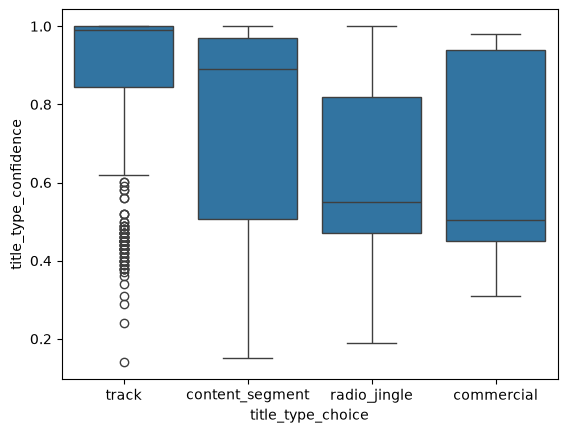

In [112]:
import seaborn as sns
sns.boxplot(data=stream_titles, x="title_type_choice", y="title_type_confidence")

In [61]:
only_tracks = stream_titles.filter(pl.col('title_type_choice') == 'track')

In [116]:
result = only_tracks.select(
    count_below_q1=(pl.col("title_type_confidence") < pl.col("title_confidence").quantile(0.1)).sum(),
    count_below_60=(pl.col("title_type_confidence") < 0.60).sum()
)
result, only_tracks.select(pl.col('title_choice').count()), result/only_tracks.select(pl.col('title_choice').count())

(shape: (1, 2)
 ┌────────────────┬────────────────┐
 │ count_below_q1 ┆ count_below_60 │
 │ ---            ┆ ---            │
 │ u32            ┆ u32            │
 ╞════════════════╪════════════════╡
 │ 36             ┆ 77             │
 └────────────────┴────────────────┘,
 shape: (1, 1)
 ┌──────────────┐
 │ title_choice │
 │ ---          │
 │ u32          │
 ╞══════════════╡
 │ 460          │
 └──────────────┘,
 shape: (1, 1)
 ┌────────────────┐
 │ count_below_q1 │
 │ ---            │
 │ f64            │
 ╞════════════════╡
 │ 0.078261       │
 └────────────────┘)

In [117]:
valid_titles = stream_titles.filter((pl.col('title_type_choice') == 'track') & (pl.col('title_type_confidence') >= 0.6))

In [118]:
valid_titles.select("title_choice", "primary_artist_choice", "secondary_artist_choice")

title_choice,primary_artist_choice,secondary_artist_choice
str,str,str
"""Mehrama""","""Pritam, Darshan Raval and An…","""none"""
"""Tujhe Kitna Chahne Lage""","""Arijit Singh""","""none"""
"""Hum To Tere Hi Liye The""","""Vishal Bhardwaj, Arijit Singh …","""none"""
"""Deewaniyat""","""Vishal Mishra, Kaushik-Guddu …","""none"""
"""Mere Khabo Mein Tu""","""Alka Yagnik, Kumar Sanu""","""none"""
…,…,…
"""Yeh Dooriyan""","""Pritam and Mohit Chauhan""","""none"""
"""Hands To Myself""","""Selena Gomez""","""none"""
"""Don""","""Swedish House Mafia feat. John…","""none"""


In [12]:
resolved = pl.read_csv('../musicbrainzngs_resolved_logs.csv')
resolved

input_artist,input_title,source,resolved_artist,resolved_title
str,str,str,str,str
"""Niall Horan""","""Heaven""","""musicbrainzngs""","""Niall Horan""","""Heaven"""
"""Ofenbach""","""Be mine""","""musicbrainzngs""","""Ofenbach""","""Be Mine"""
"""Milky""","""Just The Way You Are""","""musicbrainzngs""","""Milky""","""Just the Way You Are"""
"""Armaan Malik""","""Jab Tak""","""musicbrainzngs""","""Armaan Malik""","""Jab Tak"""
"""Taylor Swift""","""Blank Space""","""musicbrainzngs""","""Taylor Swift""","""Blank Space"""
…,…,…,…,…
"""Radio Caroline""","""www.radiocaroline.co.uk (16:43…","""musicbrainzngs""","""To Live and Shave in L.A.""","""1643"""
null,"""HUM BHUL GAYE RE""","""musicbrainzngs""","""Brian Silas""","""Mohe Bhul Gaye Sawaria (Aaja R…"
"""Whitney Houston""","""How Will I Know""","""musicbrainzngs""","""Walt Ribeiro""","""Whitney Houston ‘How Will I Kn…"


In [111]:
resolved.select(pl.col('input_title') == pl.col('resolved_title')).sum()

input_title
u32
165


In [119]:
resolved.select((pl.col('input_title') == pl.col('resolved_title')) & (pl.col('input_artist') == pl.col('resolved_artist'))).sum()


input_title
u32
78


In [107]:
resolved.count()

input_artist,input_title,source,resolved_artist,resolved_title
u32,u32,u32,u32,u32
354,381,381,381,381


In [164]:
resolved_jev = pl.read_csv('../test_outputs/resolved_titles.csv').unique()

In [165]:
resolved_jev.select(pl.col('input_title') == pl.col('resolved_title')).sum()

input_title
u32
148


In [166]:
resolved_jev.select((pl.col('input_title') == pl.col('resolved_title')) & (pl.col('input_artist') == pl.col('resolved_artist'))).sum()  

input_title
u32
68


In [167]:
(resolved_jev.select(pl.col('input_title') == pl.col('resolved_title')).sum() - resolved.select(pl.col('input_title') == pl.col('resolved_title')).sum())/resolved.select(pl.col('input_title') == pl.col('resolved_title')).sum()
# so about a 10% improvement in parsing

input_title
f64
2.6030e7


In [160]:
df = resolved.join(
    resolved_jev.filter(pl.col('input_title') == pl.col('resolved_title')),
    left_on='input_title',
    right_on='input_title',
    how='left'
)
df

input_artist,input_title,source,resolved_artist,resolved_title,input_artist_right,source_right,resolved_artist_right,resolved_title_right
str,str,str,str,str,str,str,str,str
"""Niall Horan""","""Heaven""","""musicbrainzngs""","""Niall Horan""","""Heaven""","""Niall HoranNiall Horan""","""musicbrainzngs""","""Niall Horan""","""Heaven"""
"""Niall Horan""","""Heaven""","""musicbrainzngs""","""Niall Horan""","""Heaven""","""Niall HoranNiall Horan""","""musicbrainzngs""","""Niall Horan""","""Heaven"""
"""Ofenbach""","""Be mine""","""musicbrainzngs""","""Ofenbach""","""Be Mine""",null,null,null,null
"""Milky""","""Just The Way You Are""","""musicbrainzngs""","""Milky""","""Just the Way You Are""",null,null,null,null
"""Armaan Malik""","""Jab Tak""","""musicbrainzngs""","""Armaan Malik""","""Jab Tak""","""Armaan Malik""","""musicbrainzngs""","""Armaan Malik""","""Jab Tak"""
…,…,…,…,…,…,…,…,…
null,"""HUM BHUL GAYE RE""","""musicbrainzngs""","""Brian Silas""","""Mohe Bhul Gaye Sawaria (Aaja R…",null,null,null,null
"""Whitney Houston""","""How Will I Know""","""musicbrainzngs""","""Walt Ribeiro""","""Whitney Houston ‘How Will I Kn…",null,null,null,null
"""Colin Crooks""","""Keep On Movin""","""musicbrainzngs""","""Codename Colin""","""Keep on Movin""",null,null,null,null


In [162]:
df.filter((pl.col('input_title') != pl.col('resolved_title')) & (pl.col('resolved_title_right')!='null'))

input_artist,input_title,source,resolved_artist,resolved_title,input_artist_right,source_right,resolved_artist_right,resolved_title_right
str,str,str,str,str,str,str,str,str
"""Fall Out Boy""","""Thnks Fr Th Mmrs""","""musicbrainzngs""","""Fall Out Boy""","""Thnks fr th Mmrs""","""Fall Out Boy""","""musicbrainzngs""","""Fall Out Boy""","""Thnks Fr Th Mmrs"""


In [ ]:
// Doesn't immediately seem like a good option for separation of artist and titles.
// Need better regex splitting b

In [101]:
stream_titles = pl.read_csv("../test_outputs/stream_titles.csv")
stream_titles

station_name,stream_title
str,str
"""Mirchi Love""","""Arijit Singh - Tujhe Kitna Cha…"
"""Mirchi Top 20""","""Shashwat Sachdev, Shilpa Rao …"
"""Bollywood 2010's""","""Arijit Singh - Binte Dil"""
"""ISHQ FM 104.8""","""Srinivas - Kaisi Hai Ye Rut"""
"""Hit FM (UKraine) - 128kb/s""","""The Second Voice - Let Me Be"""
…,…
"""Free FM Top 100 India""","""GAMPER & DADONIGAMPER & DADONI…"
"""RFM""","""BRUNO MARS - RISK IT ALL"""
"""Radio Eins""","""nur für Erwachsene"""


In [51]:
stream_titles.group_by('station_name').count()

C:\Users\Vignesh\AppData\Local\Temp\ipykernel_22764\3301339000.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  stream_titles.group_by('station_name').count()


station_name,count
str,u32
"""Radio record - Main Channel""",13
"""96.7 KISS FM - KHFI-FM Austin""",15
"""Radio RMF MAXXX""",2
"""Mirchi Love""",8
"""Nostalgie New York""",14
…,…
"""Radio Swiss Pop""",16
""" KISS - The Best Vibes & Energ…",15
"""Heart London 106.2 [MP3""",7


In [52]:
import polars as pl

bucket_size = 5

bucketed = (
    stream_titles
    .group_by("station_name")
    .len()
    # 1. Calculate numeric start boundary (e.g., 0, 5, 10, 15)
    .with_columns(
        bucket_start=(pl.col("len") // bucket_size) * bucket_size
    )
    # 2. Format string label: "0-5", "5-10", "10-15"
    .with_columns(
        bucket=pl.format("{}-{}", pl.col("bucket_start"), pl.col("bucket_start") + bucket_size)
    )
    # 3. Group by both numeric start and string label
    .group_by("bucket_start", "bucket")
    .agg(count=pl.len())
    # 4. Sort numerically by bucket_start
    .sort("bucket_start")
    # 5. Clean up output columns
    .select("bucket", "count")
)

print(bucketed)

shape: (6, 2)
┌────────┬───────┐
│ bucket ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ 0-5    ┆ 5     │
│ 5-10   ┆ 32    │
│ 10-15  ┆ 12    │
│ 15-20  ┆ 6     │
│ 40-45  ┆ 1     │
│ 55-60  ┆ 1     │
└────────┴───────┘


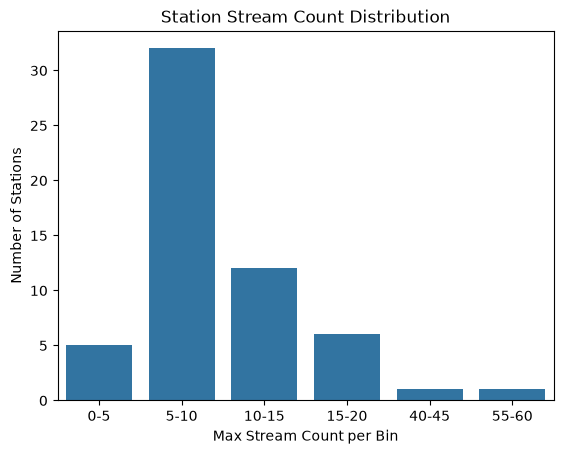

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=bucketed, x="bucket", y="count")
plt.xlabel("Max Stream Count per Bin")
plt.ylabel("Number of Stations")
plt.title("Station Stream Count Distribution")
plt.show()

In [ ]:
is_kiss_format = (
    pl.col("stream_title").str.contains(r'song_spot="+(?:M|F)"+') &
    (
        pl.col("stream_title").str.contains(r'title="+') |
        pl.col("stream_title").str.contains(r'-\s*text="+')
    )
)

is_talk_spot = pl.col("stream_title").str.contains(r'song_spot="+T"+')
is_von_format = (
    pl.col("stream_title").str.contains(r'(?i)"*([^"]+)"*\s+von\s+(.+)')
    & ~pl.col("stream_title").str.contains(r"^\*\*\*")
)
is_slash_format = (
    pl.col("stream_title").str.contains(r'^(.*?)\s*/\s*(.+)$') &
    ~pl.col("stream_title").str.contains(r'\s+-\s+')
    & ~pl.col("stream_title").str.contains(r"^\*\*\*")
)
starts_with_three_astrisk = pl.col("stream_title").str.contains(r"^\*\*\*")

stream_titles = stream_titles.with_columns(
    # --- Boolean Format Flags ---
    kiss_format_split=is_kiss_format,
    frisky_format_split=pl.col("stream_title").str.contains(r'\|\s*([^|]+?)\s*-\s*([^|]+?)\s*\|'),
    von_format_split=is_von_format,
    hyphen_split=(
        pl.col("stream_title").str.contains(r'^(.*?)\s+-\s+(.+)$')
        & ~pl.col("stream_title").str.contains(r"^\*\*\*")
        & ~p1.col("stream_title").str.contains(r"www\.")
    ),
    parsed_slash_split=is_slash_format,
    no_title_split=(
        pl.col("stream_title").str.contains(r'^\s*([^/\-"=]+?)\s*$') |
        is_talk_spot | starts_with_three_astrisk |
        pl.col("stream_title").str.contains(r"www.")
    ),

    # --- Artist Extraction ---
    artist=pl.coalesce(
        # 1. KISS format variants
        pl.when(is_kiss_format).then(
            pl.col("stream_title").str.extract(r'artist="+(.*?)"{1,2}(?:,|$|\s)', 1)
        ),
        pl.when(is_kiss_format).then(
            pl.col("stream_title").str.extract(r'([^",]+?)\s*-\s*text="+', 1)
        ),
        # 2. German "von" format (Artist is 2nd group)
        pl.when(is_von_format).then(
            pl.col("stream_title").str.extract(r'(?i)"*([^"]+)"*\s+von\s+(.+)', 2)
        ),
        # 3. Pipe-Delimited
        pl.col("stream_title").str.extract(r'\|\s*([^|]+?)\s*-\s*([^|]+?)\s*\|', 1),
        # 4. Standard: Artist - Title
        pl.col("stream_title").str.extract(r'^(.*?)\s+-\s+(.+)$', 1),
        # 5. Reversed: Title / Artist
        pl.when(is_slash_format).then(
            pl.col("stream_title").str.extract(r'^(.*?)\s*/\s*(.+)$', 2))
    ),

    # --- Title Extraction ---
    title=pl.coalesce(
        # 1. KISS format variants
        pl.when(is_kiss_format).then(
            pl.col("stream_title").str.extract(r'title="+(.*?)"{1,2}(?:,|$|\s)', 1)
        ),
        pl.when(is_kiss_format).then(
            pl.col("stream_title").str.extract(r'-\s*text="+(.*?)"{1,2}(?:\s+|$)', 1)
        ),
        # Talk spot fallbacks
        pl.when(is_talk_spot).then(
            pl.col("stream_title").str.extract(r'title="+(.*?)"{1,2}(?:,|$|\s)', 1)
        ),
        pl.when(is_talk_spot).then(
            pl.col("stream_title").str.extract(r'text="+(.*?)"{1,2}(?:\s+|$)', 1)
        ),
        # 2. German "von" format (Title is 1st group)
        pl.when(is_von_format).then(
            pl.col("stream_title").str.extract(r'(?i)"*([^"]+)"*\s+von\s+(.+)', 1)
        ),
        # 3. Pipe-Delimited
        pl.col("stream_title").str.extract(r'\|\s*[^|]+?\s*-\s*([^|]+?)\s*\|', 1),
        # 4. Standard: Artist - Title
        pl.col("stream_title").str.extract(r'^(.*?)\s+-\s+(.+)$', 2),
        # 5. Reversed: Title / Artist
        pl.when(is_slash_format).then(
            pl.col("stream_title").str.extract(r'^(.*?)\s*/\s*(.+)$', 1)),
        # 6. Plain Title Fallback
        pl.col("stream_title").str.extract(r'^\s*([^/\-"=]+?)\s*$', 1),
    )
)

NameError: name 'p1' is not defined

In [195]:
flag_cols = [
    "kiss_format_split",
    "frisky_format_split",
    "hyphen_split",
    "parsed_slash_split",
    "no_title_split",
    "von_format_split",
]

total_rows = len(stream_titles)

format_summary = (
    stream_titles
    .select(pl.col(flag_cols).sum())
    .unpivot(variable_name="format_pattern", value_name="count")
    .with_columns(
        percentage=(pl.col("count") / total_rows * 100).round(2)
    )
    .sort("count", descending=True)
)

print(format_summary)

shape: (6, 3)
┌─────────────────────┬───────┬────────────┐
│ format_pattern      ┆ count ┆ percentage │
│ ---                 ┆ ---   ┆ ---        │
│ str                 ┆ u32   ┆ f64        │
╞═════════════════════╪═══════╪════════════╡
│ hyphen_split        ┆ 435   ┆ 74.23      │
│ no_title_split      ┆ 130   ┆ 22.18      │
│ parsed_slash_split  ┆ 21    ┆ 3.58       │
│ kiss_format_split   ┆ 17    ┆ 2.9        │
│ von_format_split    ┆ 5     ┆ 0.85       │
│ frisky_format_split ┆ 2     ┆ 0.34       │
└─────────────────────┴───────┴────────────┘


In [196]:
flag_cols = [
    "kiss_format_split",
    "frisky_format_split",
    "hyphen_split",
    "parsed_slash_split",
    "no_title_split",
    "von_format_split"
]

# Breakdown by station/channel
channel_breakdown = (
    stream_titles
    .group_by("station_name")  # Replace 'station_name' with your channel column
    .agg(
        [pl.col(col).sum() for col in flag_cols] + [pl.len().alias("total_logs")]
    )
    .sort("total_logs", descending=True)
)

with pl.Config(tbl_rows=-1):
  print(channel_breakdown)


shape: (57, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ station_na ┆ kiss_forma ┆ frisky_for ┆ hyphen_sp ┆ parsed_sl ┆ no_title_ ┆ von_forma ┆ total_log │
│ me         ┆ t_split    ┆ mat_split  ┆ lit       ┆ ash_split ┆ split     ┆ t_split   ┆ s         │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆ u32        ┆ u32        ┆ u32       ┆ u32       ┆ u32       ┆ u32       ┆ u32       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ SWR3       ┆ 0          ┆ 0          ┆ 1         ┆ 18        ┆ 27        ┆ 0         ┆ 57        │
│ Radio Eins ┆ 0          ┆ 0          ┆ 0         ┆ 0         ┆ 36        ┆ 5         ┆ 41        │
│ Bayern 3   ┆ 0          ┆ 0          ┆ 7         ┆ 0         ┆ 9         ┆ 0         ┆ 16        │
│ Radio      ┆ 0          ┆ 0          ┆ 16        ┆ 0         ┆ 7         ┆

In [197]:
stream_titles = stream_titles.with_columns(
    match_count=pl.sum_horizontal(flag_cols)
)

# Distribution summary
match_summary = (
    stream_titles
    .group_by("match_count")
    .len()
    .sort("match_count")
)

print(match_summary)

shape: (3, 2)
┌─────────────┬─────┐
│ match_count ┆ len │
│ ---         ┆ --- │
│ u32         ┆ u32 │
╞═════════════╪═════╡
│ 0           ┆ 16  │
│ 1           ┆ 530 │
│ 2           ┆ 40  │
└─────────────┴─────┘


In [198]:
multi_match_df = stream_titles.filter(pl.col("match_count").is_in([2]))

for row in multi_match_df.iter_rows(named=True):
    # Find which specific boolean flags evaluated to True for this row
    active_flags = [flag for flag in flag_cols if row[flag]]
    
    print(f"FULL TITLE : {row['stream_title']}")
    print(f"MATCH COUNT: {row['match_count']}")
    print(f"MATCHED BY : {', '.join(active_flags)}")
    print("-" * 80)

FULL TITLE : FRISKY | Afterlife - NotDeadYet | for tracklist and more: FRISKY.fm
MATCH COUNT: 2
MATCHED BY : frisky_format_split, hyphen_split
--------------------------------------------------------------------------------
FULL TITLE : - text="KHFI - PROMO B - COUNTDOWN TO ACL 2026 (ALL DAY)" song_spot="T" spotInstanceId="-1" length="00:00:46" MediaBaseId="" TAID="0" TPID="0" cartcutId="" amgArtworkURL="" spEventID="68001e73-04b3-f111-83a2-0e9fc26228cf
MATCH COUNT: 2
MATCHED BY : hyphen_split, no_title_split
--------------------------------------------------------------------------------
FULL TITLE : title=" IHRPRODV- CHR - PRODUCT - 2",artist="null",url="song_spot="F" MediaBaseId="0" itunesTrackId="0" amgTrackId="-1" amgArtistId="0" TAID="0" TPID="0" cartcutId="0" amgArtworkURL="null" length="00:00:30" unsID="-1" spotInstanceId="e0d2e923-ad79-413d-b7ab-41645f679134
MATCH COUNT: 2
MATCHED BY : kiss_format_split, hyphen_split
------------------------------------------------------------

In [193]:
multi_match_df = stream_titles.filter(pl.col("no_title_split") == False)

for row in multi_match_df.iter_rows(named=True):
    # Find which specific boolean flags evaluated to True for this row
    active_flags = [flag for flag in flag_cols if row[flag]]

    print(f"FULL TITLE : {row['artist']}")
    print(f"MATCH COUNT: {row['title']}")
    print(f"MATCHED BY : {', '.join(active_flags)}")
    print("-" * 80)

FULL TITLE : Arijit Singh
MATCH COUNT: Tujhe Kitna Chahne Lage
MATCHED BY : hyphen_split
--------------------------------------------------------------------------------
FULL TITLE : Shashwat Sachdev, Shilpa Rao  and  Ujwal Gupta
MATCH COUNT: Ghafoor
MATCHED BY : hyphen_split
--------------------------------------------------------------------------------
FULL TITLE : Arijit Singh
MATCH COUNT: Binte Dil
MATCHED BY : hyphen_split
--------------------------------------------------------------------------------
FULL TITLE : Srinivas
MATCH COUNT: Kaisi Hai Ye Rut
MATCHED BY : hyphen_split
--------------------------------------------------------------------------------
FULL TITLE : The Second Voice
MATCH COUNT: Let Me Be
MATCHED BY : hyphen_split
--------------------------------------------------------------------------------
FULL TITLE : Benson Boone
MATCH COUNT: Sorry I'm Here For Someone Else
MATCHED BY : hyphen_split
----------------------------------------------------------------------

In [177]:
with pl.Config(fmt_str_lengths=1000, tbl_rows=100):
    print(stream_titles.filter(pl.col("no_title_split"))["stream_title"])

shape: (106,)
Series: 'stream_title' [str]
[
	"RMF MAXX"
	"*** Bayern 3 - Bayerns Hitradio Nummer 1 mit allen Hits von heute – und den meisten neuen!"
	"radioeins ab drei mit Hendrik Schröder"
	"MOVE mit Michael Wirbitzky & Sascha Zeus"
	"nur für Erwachsene"
	"radioeins ab drei mit Hendrik Schröder"
	"MOVE mit Michael Wirbitzky & Sascha Zeus"
	"www.radioeins.de"
	"MOVE mit Michael Wirbitzky & Sascha Zeus"
	"1LIVE"
	"MOVE mit Michael Wirbitzky & Sascha Zeus"
	"MOVE mit Michael Wirbitzky & Sascha Zeus"
	"MOVE mit Michael Wirbitzky & Sascha Zeus"
	"AD_START_120"
	"Nostalgie NY Radio"
	"MOVE mit Michael Wirbitzky & Sascha Zeus"
	"*** Bayern 3 - Bayerns Hitradio Nummer 1 mit allen Hits von heute – und den meisten neuen!"
	"free fm top 100 muje v2rFrases Top fijas"
	"MOVE mit Michael Wirbitzky & Sascha Zeus"
	"Unknown"
	"Du hörst HIT RADIO FFH"
	"SWR3 MOVE   Die Feierabendshow"
	"Nostalgie NY Radio"
	"SWR3 MOVE   Die Feierabendshow"
	"*** Bayern 3 - Bayerns Hitradio Nummer 1 mit allen Hits v

In [ ]:
# So current splitting is reasonable, we get around 80% of valid titles.
# Now we need to validate that these written titles and artists get matched exactly with values from musicbrainz api.